# Objective

* Configure the R environment within a Jupyter Notebook.

* Utilize R to perform and present statistical analysis on a selected dataset.

*Scenario: An analyst at a healthcare research firm needs to analyze patient data to predict health outcomes based on various demographic and clinical factors. Using linear regression or classification techniques, the analyst will use R to explore the relationships between these factors.*

*Learner's Role: As the analyst, you are tasked with setting up the necessary tools, selecting a dataset, and conducting a detailed analysis to extract meaningful insights that could inform future healthcare decisions.*

***

# Environment Setup
* R kernel is integrated into Jupyter Notebook

In [42]:
print("R code is running successfully!")

[1] "R code is running successfully!"


***
# Data Selection
* Choose a dataset containing at least one numerical variable and two categorical variables. 

~ I chose the heart disease UCI dataset I've used for previous projects

**Load Dataset**

In [43]:
heart_data <- read.csv("data/heart_disease_uci.csv") # Load the dataset
summary(heart_data) # Get a summary of the dataset
head(heart_data) # View the first few rows of the dataset

       id             age            sex              dataset         
 Min.   :  1.0   Min.   :28.00   Length:920         Length:920        
 1st Qu.:230.8   1st Qu.:47.00   Class :character   Class :character  
 Median :460.5   Median :54.00   Mode  :character   Mode  :character  
 Mean   :460.5   Mean   :53.51                                        
 3rd Qu.:690.2   3rd Qu.:60.00                                        
 Max.   :920.0   Max.   :77.00                                        
                                                                      
      cp               trestbps          chol          fbs         
 Length:920         Min.   :  0.0   Min.   :  0.0   Mode :logical  
 Class :character   1st Qu.:120.0   1st Qu.:175.0   FALSE:692      
 Mode  :character   Median :130.0   Median :223.0   TRUE :138      
                    Mean   :132.1   Mean   :199.1   NA's :90       
                    3rd Qu.:140.0   3rd Qu.:268.0                  
                    Max.

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<lgl>,<chr>,<int>,<lgl>,<dbl>,<chr>,<int>,<chr>,<int>
1,1,63,Male,Cleveland,typical angina,145,233,TRUE,lv hypertrophy,150,FALSE,2.3,downsloping,0,fixed defect,0
2,2,67,Male,Cleveland,asymptomatic,160,286,FALSE,lv hypertrophy,108,TRUE,1.5,flat,3,normal,2
3,3,67,Male,Cleveland,asymptomatic,120,229,FALSE,lv hypertrophy,129,TRUE,2.6,flat,2,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130,250,FALSE,normal,187,FALSE,3.5,downsloping,0,normal,0
5,5,41,Female,Cleveland,atypical angina,130,204,FALSE,lv hypertrophy,172,FALSE,1.4,upsloping,0,normal,0
6,6,56,Male,Cleveland,atypical angina,120,236,FALSE,normal,178,FALSE,0.8,upsloping,0,normal,0


***
**Understand the Variables**

The dataset shows data types of int, chr, lgl, and dbl
* <int> (Integer): Represents whole numbers (e.g., 1L, 5L, -10L). They are used for counting.
* <chr> (Character): Represents text or strings (e.g., "apple", "name", "123").
* <lgl> (Logical): Represents Boolean values used for TRUE/FALSE conditions, or NA.
* <dbl> (Double): Represents numeric data, specifically "double-precision floating-point numbers" (decimals) (e.g., 1.5, 3.14, 100.0).

*These types are crucial for determining what kind of operations can be performed on the data. Together, int and dbl are often referred to as numeric data.*
*This is important to identify because the model treats variables differently*

In [44]:
str(heart_data) # Check the structure of the dataset to understand the data types of each column

'data.frame':	920 obs. of  16 variables:
 $ id      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ age     : int  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : chr  "Male" "Male" "Male" "Male" ...
 $ dataset : chr  "Cleveland" "Cleveland" "Cleveland" "Cleveland" ...
 $ cp      : chr  "typical angina" "asymptomatic" "asymptomatic" "non-anginal" ...
 $ trestbps: int  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : int  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : logi  TRUE FALSE FALSE FALSE FALSE FALSE ...
 $ restecg : chr  "lv hypertrophy" "lv hypertrophy" "lv hypertrophy" "normal" ...
 $ thalch  : int  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : logi  FALSE TRUE TRUE FALSE FALSE FALSE ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : chr  "downsloping" "flat" "flat" "downsloping" ...
 $ ca      : int  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : chr  "fixed defect" "normal" "reversable defect" "normal" ...
 $ num     : int  0 2 1 0 0 0 3 0 2

***
**Convert Categorical Variables *AND* the Target Variable to Factors**
* Categorical Variables must be converted to factors so that statistical models treat them correctly. If left as character variables, the model may not interpret them properly.
* Target Variable (num) must be converted to a factor to allow logistic regression classification. In R, categorical outcomes must be factors for classification models.

In [45]:
heart_data$sex <- as.factor(heart_data$sex) # Convert'sex' to a factor variable
heart_data$cp <- as.factor(heart_data$cp) # Convert 'cp' to a factor variable
heart_data$dataset <- as.factor(heart_data$dataset) # Convert 'dataset' to a factor variable
heart_data$restecg <- as.factor(heart_data$restecg) # Convert 'restecg' to a factor variable
heart_data$exang <- as.factor(heart_data$exang) # Convert 'exang' to a factor variable
heart_data$slope <- as.factor(heart_data$slope) # Convert 'slope' to a factor variable
heart_data$ca <- as.factor(heart_data$ca) # Convert 'ca' to a factor variable because it represents the number of major vessels (0-3) colored by fluoroscopy, which is a categorical variable
heart_data$thal <- as.factor(heart_data$thal) # Convert 'thal' to a factor variable

str(heart_data) # Check the structure again to confirm the changes
summary(heart_data) # Get a summary of the dataset again to see the changes in the factor variables

'data.frame':	920 obs. of  16 variables:
 $ id      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ age     : int  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : Factor w/ 2 levels "Female","Male": 2 2 2 2 1 2 1 1 2 2 ...
 $ dataset : Factor w/ 4 levels "Cleveland","Hungary",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ cp      : Factor w/ 4 levels "asymptomatic",..: 4 1 1 3 2 2 1 1 1 1 ...
 $ trestbps: int  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : int  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : logi  TRUE FALSE FALSE FALSE FALSE FALSE ...
 $ restecg : Factor w/ 4 levels "","lv hypertrophy",..: 2 2 2 3 2 3 2 3 2 2 ...
 $ thalch  : int  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : Factor w/ 2 levels "FALSE","TRUE": 1 2 2 1 1 1 1 2 1 2 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : Factor w/ 4 levels "","downsloping",..: 2 3 3 2 4 4 2 4 3 2 ...
 $ ca      : Factor w/ 4 levels "0","1","2","3": 1 4 3 1 1 1 3 1 2 1 ...
 $ thal    : Factor w/ 4 l

       id             age            sex               dataset   
 Min.   :  1.0   Min.   :28.00   Female:194   Cleveland    :304  
 1st Qu.:230.8   1st Qu.:47.00   Male  :726   Hungary      :293  
 Median :460.5   Median :54.00                Switzerland  :123  
 Mean   :460.5   Mean   :53.51                VA Long Beach:200  
 3rd Qu.:690.2   3rd Qu.:60.00                                   
 Max.   :920.0   Max.   :77.00                                   
                                                                 
               cp         trestbps          chol          fbs         
 asymptomatic   :496   Min.   :  0.0   Min.   :  0.0   Mode :logical  
 atypical angina:174   1st Qu.:120.0   1st Qu.:175.0   FALSE:692      
 non-anginal    :204   Median :130.0   Median :223.0   TRUE :138      
 typical angina : 46   Mean   :132.1   Mean   :199.1   NA's :90       
                       3rd Qu.:140.0   3rd Qu.:268.0                  
                       Max.   :200.0   Max.   

***
**Convert Target Variable (num) to Binary**
* 0 = No Disease
* 1 = Disease

In [46]:
heart_data$num <- ifelse(heart_data$num == 0, 0, 1)
heart_data$num <- as.factor(heart_data$num) # Convert 'num' to a factor variable for classification purposes

levels(heart_data$num) <- c("No Disease", "Disease") # Label the levels of 'num' for better interpretability

table(heart_data$num) # Check the distribution of the target variable 'num' to see how many cases of heart disease (1) and no heart disease (0) are in the dataset


No Disease    Disease 
       411        509 

*The dataset contains 411 patients without disease and 509 with disease, indicating a relatively balanced distribution*

***
# Statistical Analysis

**Library Usage**
* Load necessary R libraries such as ggplot2 for visualization, dplyr for data manipulation, and stats for performing regression or classification.

In [47]:
library(tidyverse) # Load the tidyverse package for data manipulation and visualization
library(caret) # Load the caret package for machine learning

**Split Training / Testing Data**
* Load caret package (done in step above ⬆️)
* Set the seed (so the split is reproducible) ⬇️
* Split Data ⬇️

In [48]:
set.seed(123) # Set a seed for reproducibility
train_index <- createDataPartition(heart_data$num, p = 0.7, list = FALSE) # Create a partition index for splitting the data into training (70%) and testing (30%) sets, ensuring that the distribution of the target variable 'num' is maintained in both sets
train_data <- heart_data[train_index, ] # Create the training dataset
test_data <- heart_data[-train_index, ] # Create the testing dataset

**Verify the Split Worked**
* training (70%) and testing (30%)

In [49]:
dim(train_data)
dim(test_data)

[1] 645  16

[1] 275  16

Train: 645 rows; Test: 275 rows; 16 columns

- 70% training 
- 30% testing   
Same number of columns (16)

*The dataset was split into training and testing sets using a 70/30 ratio. The training set contained 645 observations, while the testing set contained 275 observations. This allows the model to be trained on one portion of the data and evaluated on unseen data to assess performance.*

***
**Model Building**
* For linear regression, use the lm() function to model the relationship between the numerical response variable and other predictors.
* For logistic regression *(classification)*, use functions like glm() with a logistic link if the response variable is categorical.
    * glm() stands for generalized linear model
    * family = binomial - *binary outcomes becomes logistic regression*

Train the Model:

In [51]:
heart_model <- glm(num ~ age + sex + cp + trestbps + chol + thalch + exang,
data = train_data, 
family = binomial) # Fit a logistic regression model using the training data, with 'num' as the target variable and all other columns as predictors

summary(heart_model) # Get a summary of the fitted model to evaluate the significance of each predictor variable and the overall model fit


Call:
glm(formula = num ~ age + sex + cp + trestbps + chol + thalch + 
    exang, family = binomial, data = train_data)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)       -0.740604   1.293573  -0.573 0.566966    
age                0.033937   0.013341   2.544 0.010964 *  
sexMale            1.111150   0.288044   3.858 0.000115 ***
cpatypical angina -2.306024   0.336751  -6.848 7.50e-12 ***
cpnon-anginal     -1.659627   0.279065  -5.947 2.73e-09 ***
cptypical angina  -0.959716   0.444091  -2.161 0.030689 *  
trestbps           0.011469   0.006273   1.828 0.067497 .  
chol              -0.003207   0.001170  -2.742 0.006110 ** 
thalch            -0.015538   0.005030  -3.089 0.002009 ** 
exangTRUE          1.210036   0.248161   4.876 1.08e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 798.38  on 581  degrees of freedom
Residual deviance: 494.2

* Coefficient tells you whether a variable is associated with a higher or lower likelihood of heart disease
    * positive coefficient = increases likelihood
    * negative coefficient = decreases likelihood
    * smaller p-value = more statistically important   
* p-value helps you judge whether a variable is likely related to the outcome
    * strong significance for sex, chest pain, exang
    * significance for age, cholesterol, thalch
    * borderline significance for trestbps
* Significance Stars evaluate the significance of each predictor variable
    * ` Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 `

*The logistic regression results indicate that several variables are significantly associated with heart disease. In particular, sex, chest pain type, and exercise-induced angina showed strong statistical significance. Age, cholesterol levels, and maximum heart rate also contributed to predicting heart disease outcomes. These findings suggest that both demographic and clinical factors play an important role in determining heart disease risk.*

***
**Model Evaluation**
* Assess the model's performance using appropriate metrics such as R-squared for regression or accuracy/confusion matrix for classification.

Predictions & Accuracy:

In [60]:
predicted_prob <- predict(heart_model, newdata = test_data, type = "response")

predicted_class <- ifelse(predicted_prob > 0.5, "Disease", "No Disease")
predicted_class <- factor(predicted_class, levels = c("No Disease", "Disease"))

test_data$num <- factor(test_data$num, levels = c("No Disease", "Disease"))

confusion_matrix <- confusionMatrix(predicted_class, test_data$num)
print(confusion_matrix)

Confusion Matrix and Statistics

            Reference
Prediction   No Disease Disease
  No Disease         88      27
  Disease            29     108
                                          
               Accuracy : 0.7778          
                 95% CI : (0.7213, 0.8276)
    No Information Rate : 0.5357          
    P-Value [Acc > NIR] : 1.362e-15       
                                          
                  Kappa : 0.5528          
                                          
 Mcnemar's Test P-Value : 0.8937          
                                          
            Sensitivity : 0.7521          
            Specificity : 0.8000          
         Pos Pred Value : 0.7652          
         Neg Pred Value : 0.7883          
             Prevalence : 0.4643          
         Detection Rate : 0.3492          
   Detection Prevalence : 0.4563          
      Balanced Accuracy : 0.7761          
                                          
       'Positive' Class : No Dis

*The model was evaluated using a confusion matrix, which compares predicted classifications to actual outcomes. Accuracy was used as a primary metric to assess model performance. The results demonstrate that the model is able to reasonably predict heart disease with 78% accuracy based on selected variables.*

***
# Visualization
**Visualizations to support findings, using plots like scatter plots for regression or bar charts for classification outcomes.**
* I will use a bar chart for this assignment since the target variable is categorical

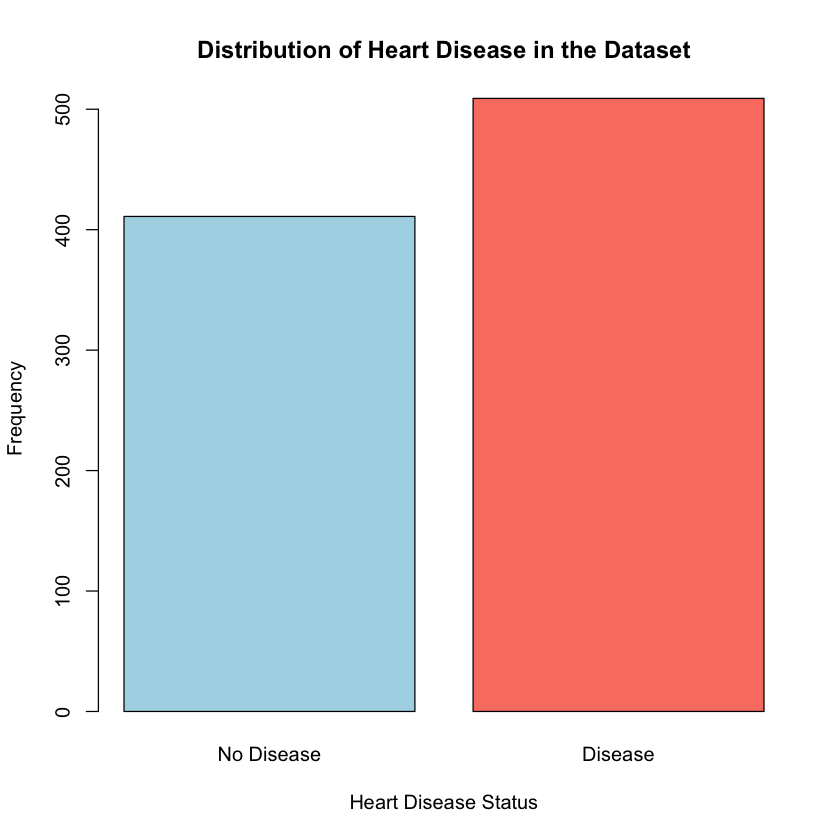

In [61]:
barplot(table(heart_data$num), 
main = "Distribution of Heart Disease in the Dataset", 
xlab = "Heart Disease Status", ylab = "Frequency", col = c("lightblue", "salmon")) # Create a bar plot to visualize the distribution of heart disease in the dataset, showing the frequency of cases with and without heart disease


***
# Summary

I set up the R kernel in Jupyter so I could run R code in VS Code. Then I loaded a heart disease CSV file into R and inspected the dataset using head(), str(), and summary(). After that, I converted the categorical columns into factors so R would treat them correctly in the model. I changed the target variable into a binary outcome where 0 meant no heart disease and 1 meant disease. Next, I split the data into training and testing sets using a 70/30 split. I built a logistic regression model using demographic and clinical variables, then generated predictions on the test set. Finally, I evaluated the model with a confusion matrix and found that the model achieved about 78% accuracy.